# Statistics with Airline Passenger Data

A simple introduction to descriptive statistics, trends and seasonality using the local Day 2 dataset.


## Goal

Summarise monthly passenger counts and identify the main time-series patterns.


## 1. imports


In [2]:
from pathlib import Path
import calendar
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = Path("day_2/Slides-Notes/Datasets")
if not DATA_DIR.exists():
    DATA_DIR = Path("../Slides-Notes/Datasets")
sns.set_theme(style="whitegrid", context="notebook")

## 2. Load the data


In [3]:
airline = pd.read_csv(DATA_DIR / "airline-passengers.csv", parse_dates=["Month"])
airline.head()

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [4]:
print(f"Period: {airline['Month'].min():%B %Y} to {airline['Month'].max():%B %Y}")
print(f"Rows: {len(airline)} | Missing values: {airline.isna().sum().sum()}")

Period: January 1949 to December 1960
Rows: 144 | Missing values: 0


## 3. Descriptive statistics


In [5]:
passenger_stats = airline["Passengers"].agg(["count", "mean", "median", "std", "min", "max"])
passenger_stats.to_frame("Passengers").round(1)

,Passengers
count,144.0
mean,280.3
median,265.5
std,120.0
min,104.0
max,622.0


### Quartiles and range


In [6]:
q1, q3 = airline["Passengers"].quantile([0.25, 0.75])
summary = pd.Series({
    "Range": airline["Passengers"].max() - airline["Passengers"].min(),
    "Q1": q1,
    "Q3": q3,
    "IQR": q3 - q1
})
summary.to_frame("Passengers").round(1)

,Passengers
Range,518.0
Q1,180.0
Q3,360.5
IQR,180.5


## 4. View the trend

A 12-month moving average smooths the seasonal movement and makes the long-term direction clearer.


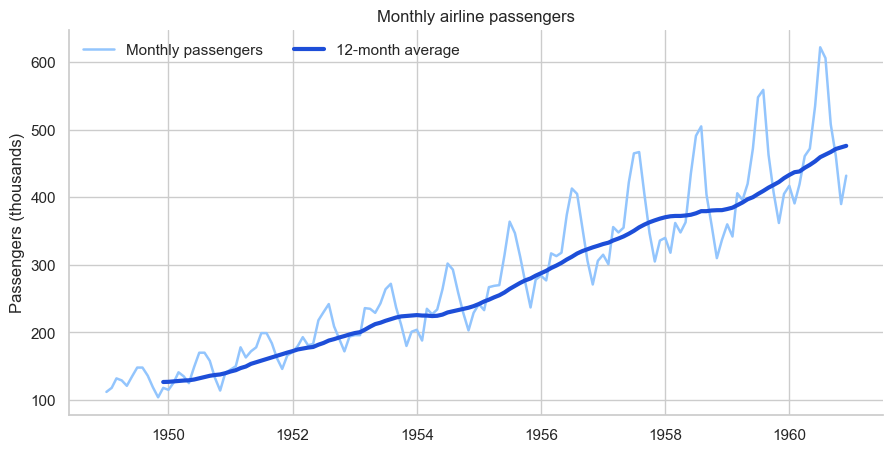

In [7]:
airline["12-month average"] = airline["Passengers"].rolling(12).mean()

fig, ax = plt.subplots(figsize=(10.5, 5))
ax.plot(airline["Month"], airline["Passengers"], color="#93C5FD", linewidth=1.8, label="Monthly passengers")
ax.plot(airline["Month"], airline["12-month average"], color="#1D4ED8", linewidth=3, label="12-month average")
ax.set(title="Monthly airline passengers", xlabel="", ylabel="Passengers (thousands)")
ax.legend(frameon=False, ncol=2, loc="upper left")
sns.despine()
plt.show()

## 5. Compare months

Averages by calendar month reveal the seasonal pattern across all 12 years.


In [8]:
airline["Month Number"] = airline["Month"].dt.month
monthly_average = airline.groupby("Month Number")["Passengers"].mean()
monthly_average.index = [calendar.month_abbr[m] for m in monthly_average.index]
monthly_average.to_frame("Average passengers").round(1)

,Average passengers
Jan,241.8
Feb,235.0
Mar,270.2
Apr,267.1
May,271.8
Jun,311.7
Jul,351.3
Aug,351.1
Sep,302.4
Oct,266.6


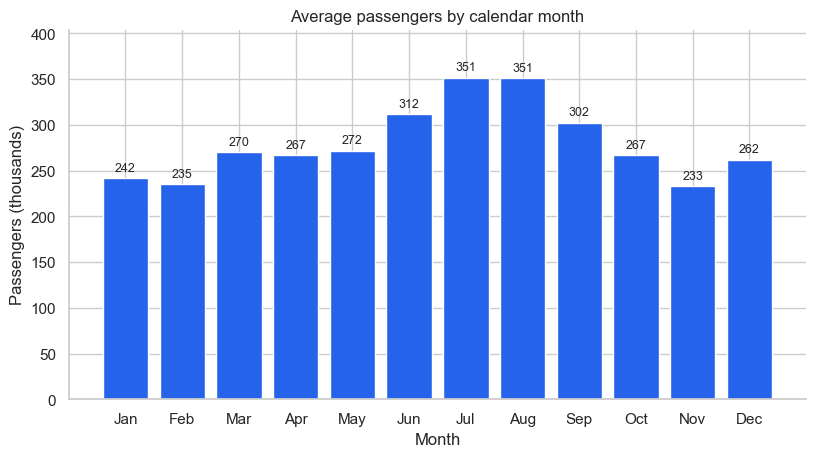

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
bars = ax.bar(monthly_average.index, monthly_average.values, color="#2563EB")
ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)
ax.set(title="Average passengers by calendar month", xlabel="Month", ylabel="Passengers (thousands)")
ax.set_ylim(0, monthly_average.max() * 1.15)
sns.despine()
plt.show()

## 6. Measure yearly growth


In [10]:
yearly = (airline.assign(Year=airline["Month"].dt.year)
          .groupby("Year")["Passengers"]
          .agg(Average="mean", Minimum="min", Maximum="max"))
yearly["Growth %"] = yearly["Average"].pct_change() * 100
yearly.round(1)

,Average,Minimum,Maximum,Growth %
Year,,,,
1949,126.7,104,148,NaN
1950,139.7,114,170,10.3
1951,170.2,145,199,21.8
1952,197.0,171,242,15.8
1953,225.0,180,272,14.2
1954,238.9,188,302,6.2
1955,284.0,233,364,18.9
1956,328.2,271,413,15.6
1957,368.4,301,467,12.2


## 7. Check unusual months

A z-score above 2 or below -2 marks a value far from the overall mean.


In [11]:
airline["z_score"] = (airline["Passengers"] - airline["Passengers"].mean()) / airline["Passengers"].std()
airline.loc[airline["z_score"].abs() > 2, ["Month", "Passengers", "z_score"]].round(2)

,Month,Passengers,z_score
126,1959-07-01,548,2.23
127,1959-08-01,559,2.32
137,1960-06-01,535,2.12
138,1960-07-01,622,2.85
139,1960-08-01,606,2.71


These high values occur near the end of a growing time series. They are unusual compared with the overall average, but they are not automatically data errors.


## my lessons learned

- Passenger totals rise strongly over the full period.
- The 12-month moving average confirms a long-term upward trend.
- July and August are typically the busiest months.
- Time order matters, so high later values should not be removed simply because they have large z-scores.
